In [1]:
import os

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tabulate import tabulate
import keras
layers = tf.keras.layers

In [2]:
os.makedirs("models", exist_ok=True)

In [3]:
def plot_examples(X, Y, n=10):
    """ Plot the first n examples for each of the 10 classes in the CIFAR dataset X, Y """
    fig, axes = plt.subplots(n, 10, figsize=(10, n))
    for l in range(10):
        axes[0, l].set_title(cifar10_labels[l], fontsize="smaller")
        m = np.squeeze(Y) == l  # boolean mask: True for all images of label l
        for i in range(n):
            image = X[m][i].astype("uint8")  # imshow expects uint8
            ax = axes[i, l]
            ax.imshow(image, origin="upper")
            ax.set(xticks=[], yticks=[])
    return fig, ax


def plot_prediction(X, Y, Y_predict):
    """
    Plot image X along with predicted probabilities Y_predict.
    X: CIFAR image, shape = (32, 32, 3)
    Y: CIFAR label, one-hot encoded, shape = (10)
    Y_predict: predicted probabilities, shape = (10)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # plot image
    ax1.imshow(X.astype("uint8"), origin="upper")
    ax1.set(xticks=[], yticks=[])

    # plot probabilities
    ax2.barh(np.arange(10), Y_predict, align="center")
    ax2.set(xlim=(0, 1), xlabel="Score", yticks=[])
    for i in range(10):
        c = "red" if (i == np.argmax(Y)) else "black"
        ax2.text(0.05, i, cifar10_labels[i].capitalize(), ha="left", va="center", color=c)


def plot_confusion(Y_true, Y_predict):
    """
    Plot confusion matrix
    Y_true:    array of true classifications (0-9), shape = (N)
    Y_predict: array of predicted classifications (0-9), shape = (N)
    """
    C = np.histogram2d(Y_true, Y_predict, bins=np.linspace(-0.5, 9.5, 11))[0]
    Cn = C / np.sum(C, axis=1)

    fig = plt.figure()
    plt.imshow(Cn, interpolation="nearest", vmin=0, vmax=1, cmap=plt.cm.YlGnBu)
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel("truth")
    plt.xticks(range(10), cifar10_labels, rotation="vertical")
    plt.yticks(range(10), cifar10_labels)
    for x in range(10):
        for y in range(10):
            plt.annotate("%i" % C[x, y], xy=(y, x), ha="center", va="center")



In [4]:

# X: images, Y: labels
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("images, shape = ", x_train.shape)
print("labels, shape = ", y_train.shape)

cifar10_labels = np.array([
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'])

n_classes = len(cifar10_labels)


images, shape =  (50000, 32, 32, 3)
labels, shape =  (50000, 1)


In [5]:
# convert labels ("0"-"9") to one-hot encodings, "0" = (1, 0, ... 0) and so on
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)[:8000]
y_valid_onehot = tf.keras.utils.to_categorical(y_test, 10)[8000:]

# Hint: normalize the data
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0
# Hint: use 20% of the test data for validation
x_valid_norm = x_test_norm[8000:]
x_test_norm = x_test_norm[:8000]


In [6]:
def dense_block(x, n=8):
    """ 
    Creates of n densely connected pairs of convolutions
    """
    xlist = [x]

    for i in range(n):
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Conv2D(8, (3,3), padding='same')(x)
        # x = layers.Conv2D(8, (3,3), padding='same', activation='relu')(x)
        x = layers.Dropout(0.2)(x)
        xlist.append(x)
        x = layers.concatenate(xlist[:], axis=-1) # axis -1 for feature space
    return x

In [7]:
# Define Model -> Dense Conv Model

        
x0 = layers.Input(shape=(32,32,3), name='input')

x = dense_block(x0)

x = layers.Conv2D(64, (1, 1), padding='same', activation='relu')(x)
x = layers.AveragePooling2D((2,2), strides=(2,2))(x)

x = dense_block(x)

# maybe add more here but first try the example from the lecture

x = layers.GlobalAveragePooling2D(name='final_globalpooling')(x)

x = layers.Dropout(0.3, name='final_dropout')(x)
x = layers.Dense(n_classes, activation='softmax')(x)

model = keras.models.Model(inputs=[x0], outputs=[x], name='DenseNet')

2026-06-12 13:42:25.453413: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-06-12 13:42:25.453579: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-06-12 13:42:25.453592: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-06-12 13:42:25.453776: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-12 13:42:25.453807: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [8]:
print(model.summary())

Model: "DenseNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32, 3) │         12 │ input[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32, 3) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32, 8) │        224 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 32, 8) │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ input[0][0],      │
│ (Concatenate)       │ 11)               │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         44 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32, 8) │        800 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32, 8) │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32,    │          0 │ input[0][0],      │
│ (Concatenate)       │ 19)               │            │ dropout[0][0],    │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         76 │ concatenate_1[0]… │
│ (BatchNormalizatio… │ 19)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 19)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32, 8) │      1,376 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 32, 8) │          0 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 32, 32,    │          0 │ input[0][0],      │
│ (Concatenate)       │ 27)               │            │ dropout[0][0],    │
│                     │                   │            │ dropout_1[0][0],  │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        108 │ concatenate_2[0]… │
│ (BatchNormalizatio… │ 27)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 27)               │            │                 

 Total params: 80,554 (314.66 KB)

 Trainable params: 78,586 (306.98 KB)

 Non-trainable params: 1,968 (7.69 KB)

None


In [ ]:
# training
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[keras.metrics.CategoricalAccuracy()],
)

model.fit(
    x_train_norm,
    y_train_onehot,
    batch_size=128,
    epochs=100,
    validation_data=(x_valid_norm, y_valid_onehot),
    callbacks=[keras.callbacks.CSVLogger("history_{}.csv".format(model.name))]
)

model.save('models/{}.keras'.format(model.name))

Epoch 1/40


2026-06-11 16:41:13.725238: I external/local_xla/xla/service/service.cc:163] XLA service 0x71c980004950 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
2026-06-11 16:41:13.725249: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): AMD Radeon RX 6950 XT, AMDGPU ISA version: gfx1030
2026-06-11 16:41:13.888076: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781196092.063320    1166 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


391/391 ━━━━━━━━━━━━━━━━━━━━ 66s 110ms/step - categorical_accuracy: 0.3402 - loss: 1.7756 - val_categorical_accuracy: 0.2875 - val_loss: 2.0694
Epoch 2/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - categorical_accuracy: 0.4629 - loss: 1.4797 - val_categorical_accuracy: 0.3635 - val_loss: 2.0870
Epoch 3/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - categorical_accuracy: 0.5101 - loss: 1.3566 - val_categorical_accuracy: 0.4475 - val_loss: 1.6208
Epoch 4/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - categorical_accuracy: 0.5441 - loss: 1.2686 - val_categorical_accuracy: 0.5440 - val_loss: 1.2974
Epoch 5/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - categorical_accuracy: 0.5728 - loss: 1.1927 - val_categorical_accuracy: 0.5725 - val_loss: 1.2969
Epoch 6/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - categorical_accuracy: 0.5961 - loss: 1.1323 - val_categorical_accuracy: 0.5540 - val_loss: 1.3184
Epoch 7/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - categorical_accuracy: 0.6111 -

/var/folders/92/vd53kdfd5v7c7_j3f5mmq2r00000gn/T/ipykernel_32444/2206430061.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


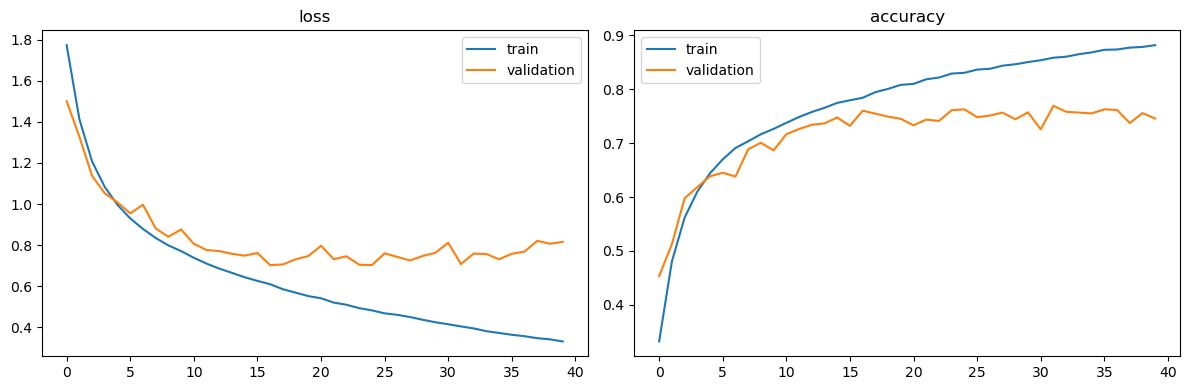

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("history_DenseNet.csv")

# plot training history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(df["loss"], label="train")
ax[0].plot(df["val_loss"], label="validation")
ax[0].set_title("loss")
ax[0].legend()

ax[1].plot(df["categorical_accuracy"], label="train")
ax[1].plot(df["val_categorical_accuracy"], label="validation")
ax[1].set_title("accuracy")
ax[1].legend()

fig.tight_layout()
fig.show()


The model visibly overtrains after about 15 epochs. Maybe a deeper network would take longer for this to take place. I somewhat improved the problem ov overtraining by adding dropout layers inside the dense blocks, as well as afterwards. Maybe I'd need to increase the dropout to help against the overtraing.

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step


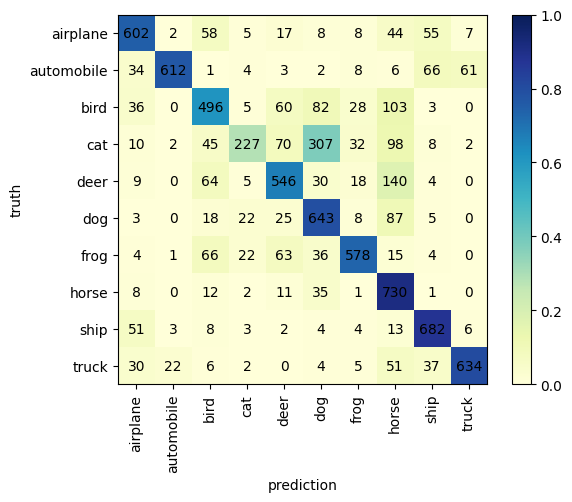

In [19]:
y_predict = model.predict(x_test_norm, batch_size=128)

# convert back to class labels (0-9)
y_predict_cl = np.argmax(y_predict, axis=1)
y_test_cl = np.argmax(y_test_onehot, axis=1)

# plot confusion matrix
plot_confusion(y_test_cl, y_predict_cl)

The Matrix looks similar to the one of the CNN of the previous task. Interestingly the model seems to have a bias towards identifying many of the animals as horses. The confusion between dog and cat is present again. There is some improvement on the front of trucks being predicted to be cars.